# Partie 1 - Données tabulaires

In [1]:
from data_analysis import *
import pandas as pd

## 1. Analyse du jeu de données

### Utilisez ce que nous avons vu pendant les TPs. En utilisant les librairies panda et seaborn, indiquez par exemple si le jeu de données contient des données manquantes, explorez les différentes colonnes (type, modalités, plages de valeurs, cardinal, distributions, etc). 

#### Analyse du jeu de données - pas de preprocessing

In [2]:
df = pd.read_csv("RH_dataset.csv", sep=';', encoding='utf-8')
analysis_RH_raw=Analyzer(df)

Dataset ready: 23857 rows and 14 columns.


In [3]:
analysis_RH_raw.df.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')

In [4]:
analysis_RH_raw.get_inventory()

,Column,Type,Cardinality,Missing,Details
0,Famille d'emploi,str,8,0,"Unique values: ['Production', 'Commercial/Busi..."
1,Dernière promotion (mois),float64,7670,0,"Range: [0.0, 152.97000122070312]"
2,Dernière augmentation (mois),float64,2934,0,"Range: [0.0, 84.05000305175781]"
3,Début de contrat (années),float64,2433,0,"Range: [0.0, 33.119998931884766]"
4,Ancienneté groupe (années),float64,3660,0,"Range: [0.0, 45.619998931884766]"
5,Etablissement,int64,35,0,"Range: [0, 36]"
6,Âge (années),int64,74,0,"Range: [20, 100]"
7,Parent,int64,2,0,"Unique values: [1, 0]"
8,Niveau hiérarchique,int64,4,0,"Unique values: [1, 2, 3, 4]"
9,Salaire (Euros),int64,4901,0,"Range: [2134, 18137]"


On plote les distributions sur toutes les colonnes numériques.

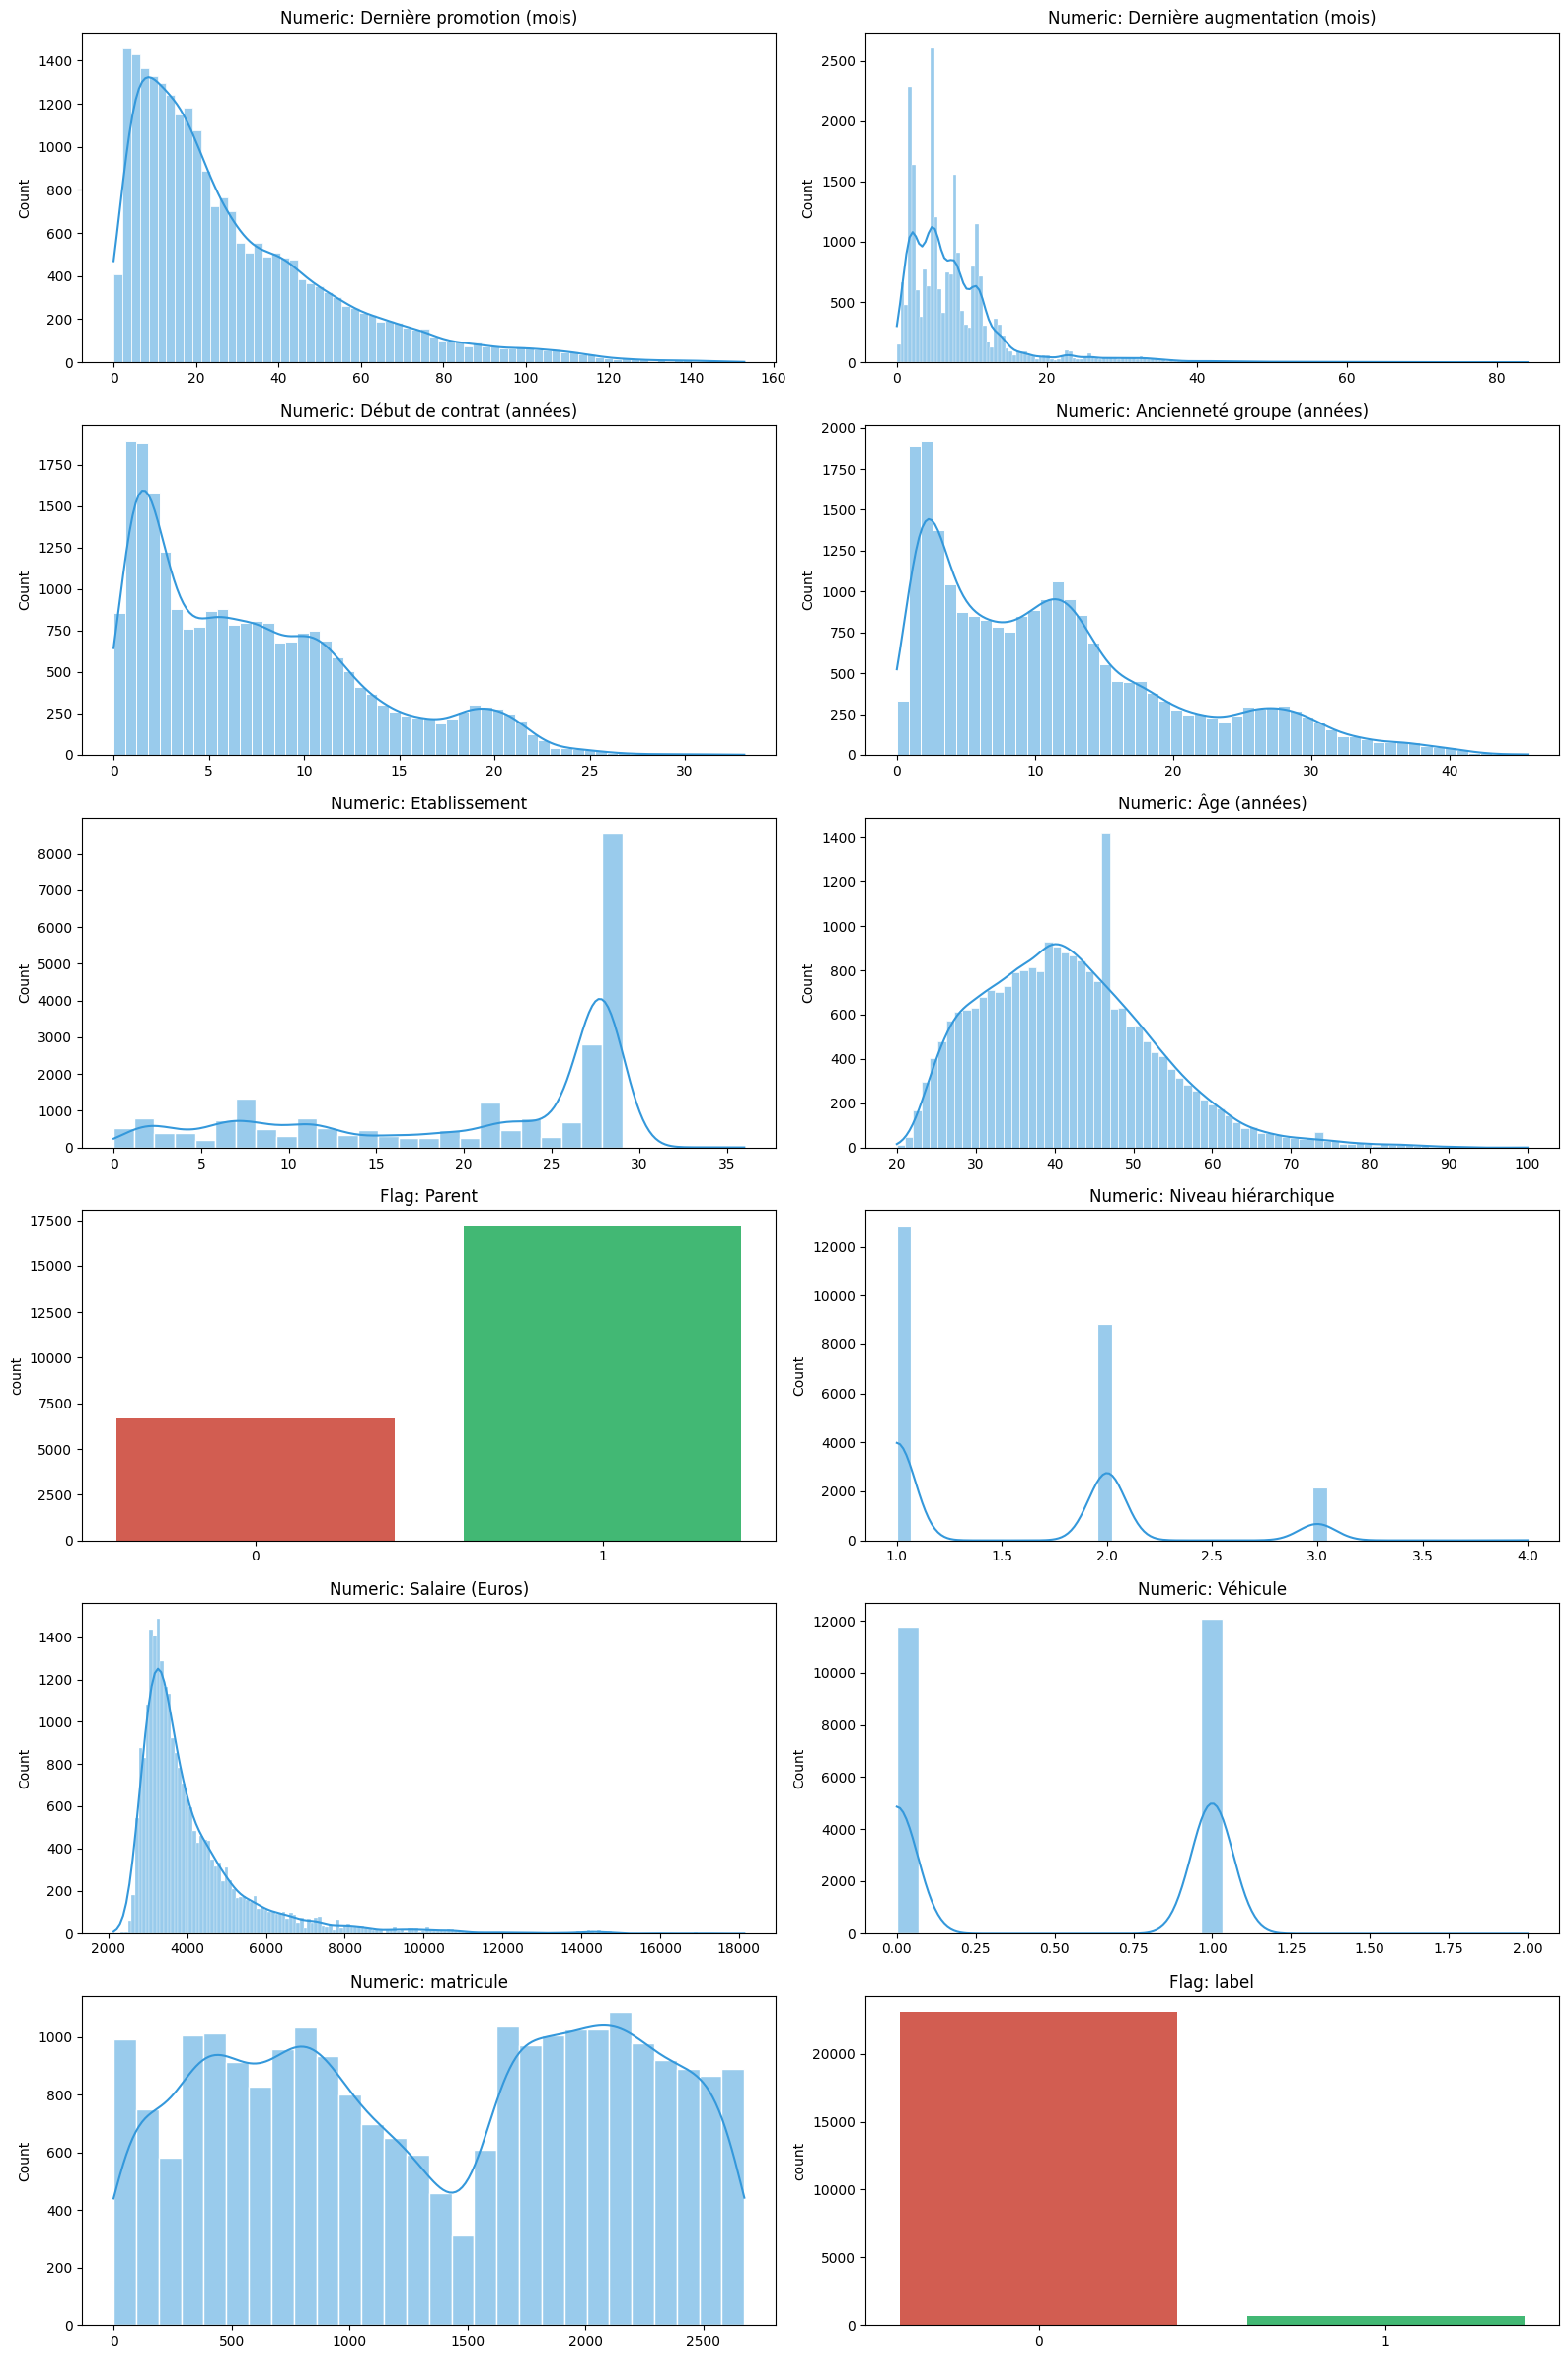

In [5]:
analysis_RH_raw.plot_distributions(['Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Véhicule',
       'matricule', 'label'])

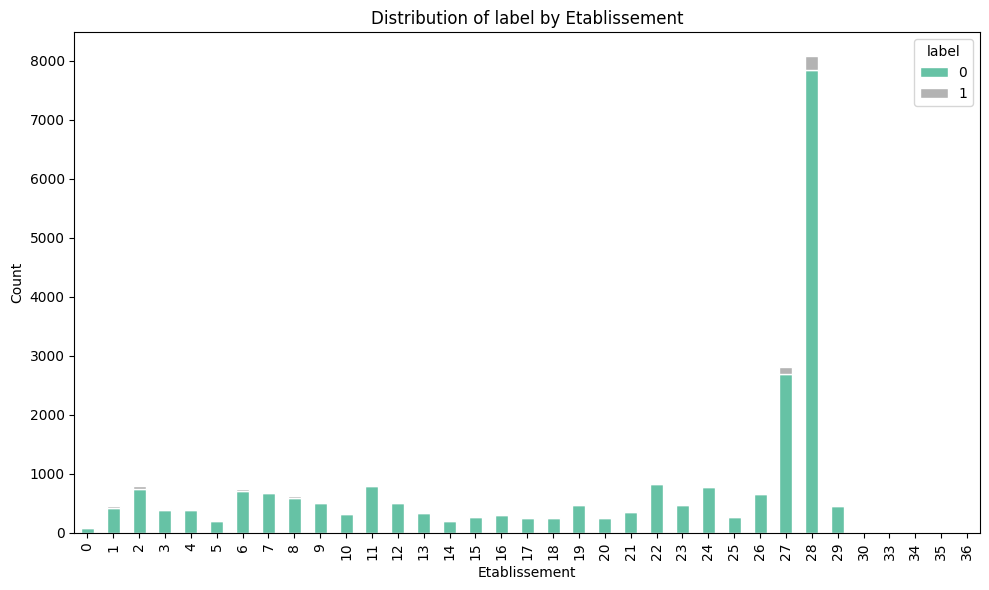

In [6]:
ct = pd.crosstab(df['Etablissement'], df['label'])

ct.plot(
    kind='bar',
    stacked=True,
    colormap='Set2',
    edgecolor='white',
    figsize=(10, 6)
)

plt.xlabel("Etablissement")
plt.ylabel("Count")
plt.title("Distribution of label by Etablissement")
plt.legend(title="label")
plt.tight_layout()
plt.show()

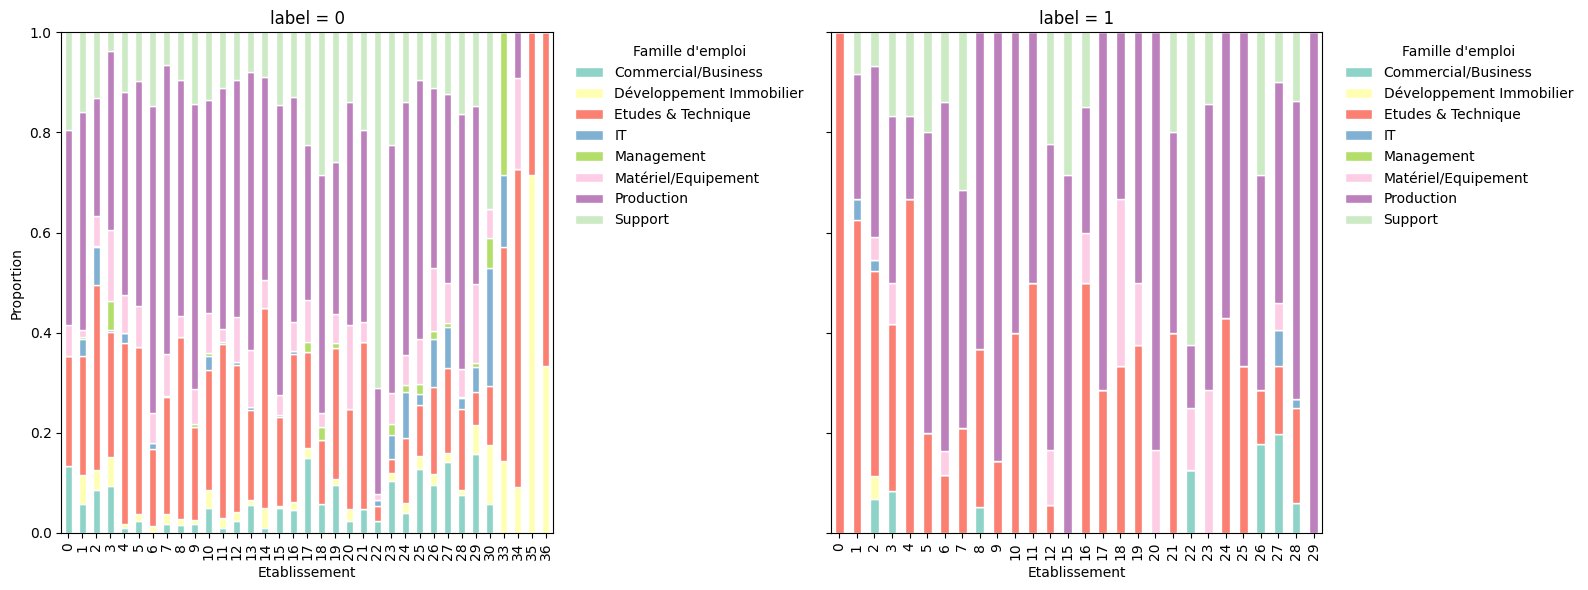

In [7]:
analysis_RH_raw.plot_crosstab(
    'Etablissement',
    groupby="Famille d'emploi",
    splitby="label"
)

#### Preprocessing sur les colonnes catégorielles

In [8]:
processed=DataPreprocessor(df).handle_encoding()

Encoding columns: ["Famille d'emploi", 'Statut marital']
Encoding complete. New shape: (23857, 29)


#### Analyse du jeu de données - après preprocessing des colonnes catégorielles

In [9]:
analysis_RH=Analyzer(processed)
analysis_RH.df.columns

Dataset ready: 23857 rows and 29 columns.


Index(['Dernière_promotion_mois', 'Dernière_augmentation_mois',
       'Début_de_contrat_années', 'Ancienneté_groupe_années', 'Etablissement',
       'Âge_années', 'Parent', 'Niveau_hiérarchique', 'Salaire_Euros',
       'Véhicule', 'matricule', 'label', 'Famille_demploi_Commercial_Business',
       'Famille_demploi_Développement_Immobilier',
       'Famille_demploi_Etudes_&_Technique', 'Famille_demploi_IT',
       'Famille_demploi_Management', 'Famille_demploi_Matériel_Equipement',
       'Famille_demploi_Production', 'Famille_demploi_Support',
       'Statut_marital_Concubin', 'Statut_marital_Célibataire',
       'Statut_marital_Divorcée', 'Statut_marital_Mariée',
       'Statut_marital_PACS', 'Statut_marital_Séparée',
       'Statut_marital_Union_libre', 'Statut_marital_Veufve',
       'Statut_marital_ex_PACS'],
      dtype='str')

In [10]:
analysis_RH.get_inventory()

,Column,Type,Cardinality,Missing,Details
0,Dernière_promotion_mois,float64,7670,0,"Range: [0.0, 152.97000122070312]"
1,Dernière_augmentation_mois,float64,2934,0,"Range: [0.0, 84.05000305175781]"
2,Début_de_contrat_années,float64,2433,0,"Range: [0.0, 33.119998931884766]"
3,Ancienneté_groupe_années,float64,3660,0,"Range: [0.0, 45.619998931884766]"
4,Etablissement,int64,35,0,"Range: [0, 36]"
5,Âge_années,int64,74,0,"Range: [20, 100]"
6,Parent,int64,2,0,"Unique values: [1, 0]"
7,Niveau_hiérarchique,int64,4,0,"Unique values: [1, 2, 3, 4]"
8,Salaire_Euros,int64,4901,0,"Range: [2134, 18137]"
9,Véhicule,int64,3,0,"Unique values: [0, 1, 2]"


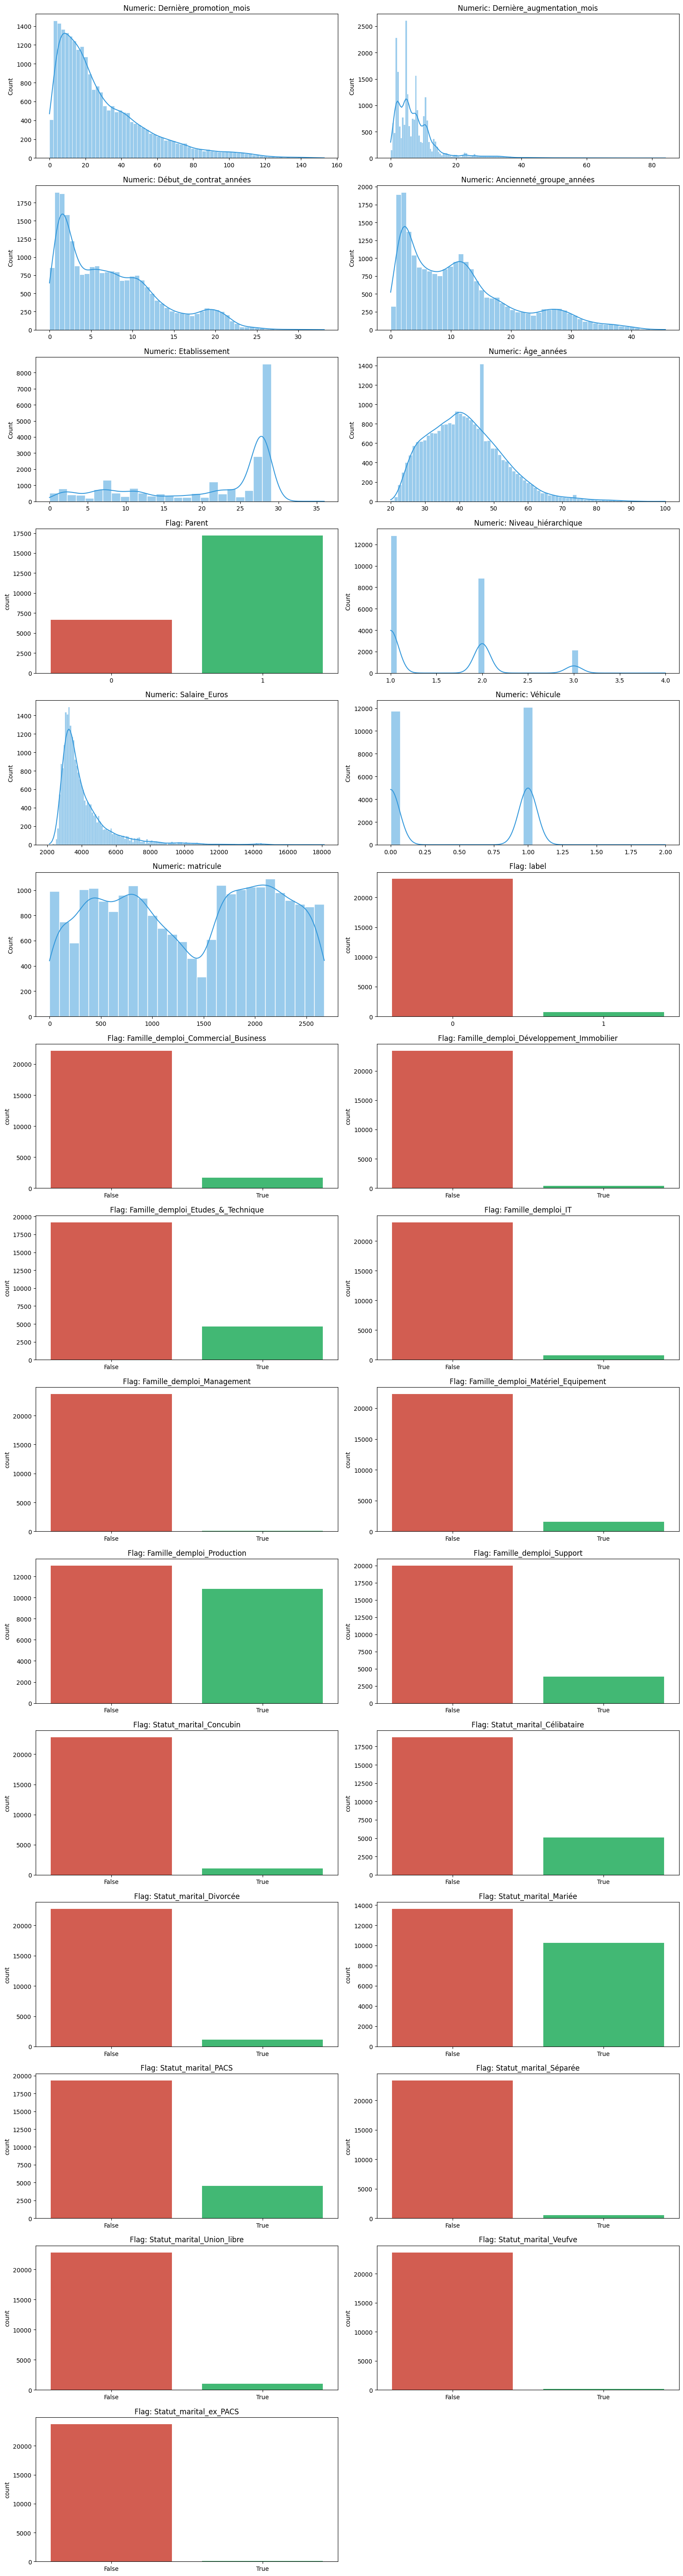

In [11]:
analysis_RH.plot_distributions(['Dernière_promotion_mois', 'Dernière_augmentation_mois',
       'Début_de_contrat_années', 'Ancienneté_groupe_années', 'Etablissement',
       'Âge_années', 'Parent', 'Niveau_hiérarchique', 'Salaire_Euros',
       'Véhicule', 'matricule', 'label', 'Famille_demploi_Commercial_Business',
       'Famille_demploi_Développement_Immobilier',
       'Famille_demploi_Etudes_&_Technique', 'Famille_demploi_IT',
       'Famille_demploi_Management', 'Famille_demploi_Matériel_Equipement',
       'Famille_demploi_Production', 'Famille_demploi_Support',
       'Statut_marital_Concubin', 'Statut_marital_Célibataire',
       'Statut_marital_Divorcée', 'Statut_marital_Mariée',
       'Statut_marital_PACS', 'Statut_marital_Séparée',
       'Statut_marital_Union_libre', 'Statut_marital_Veufve',
       'Statut_marital_ex_PACS'])

### Il y a-t-il des valeurs manquantes ?

In [12]:
CATEGORIES = {
    "Profil employé":          ["Âge (années)", "Statut marital", "Parent", "matricule"],
    "Contrat & Ancienneté":    ["Début de contrat (années)", "Ancienneté groupe (années)", "Etablissement", "Famille d'emploi"],
    "Rémunération":            ["Salaire (Euros)", "Véhicule", "Dernière augmentation (mois)", "Dernière promotion (mois)"],
    "Hiérarchie":              ["Niveau hiérarchique"],
    "Cible":                   ["label"],
}

for cat, cols in CATEGORIES.items():
    cols_ok = [c for c in cols if c in df.columns]
    print(f"\n── {cat} ──")
    for col in cols_ok:
        n = df[col].isnull().sum()
        pct = n / len(df) * 100
        print(f"  {col:<35} {n:>5} NaN  ({pct:.1f}%)")


── Profil employé ──
  Âge (années)                            0 NaN  (0.0%)
  Statut marital                          0 NaN  (0.0%)
  Parent                                  0 NaN  (0.0%)
  matricule                               0 NaN  (0.0%)

── Contrat & Ancienneté ──
  Début de contrat (années)               0 NaN  (0.0%)
  Ancienneté groupe (années)              0 NaN  (0.0%)
  Etablissement                           0 NaN  (0.0%)
  Famille d'emploi                        0 NaN  (0.0%)

── Rémunération ──
  Salaire (Euros)                         0 NaN  (0.0%)
  Véhicule                                0 NaN  (0.0%)
  Dernière augmentation (mois)            0 NaN  (0.0%)
  Dernière promotion (mois)               0 NaN  (0.0%)

── Hiérarchie ──
  Niveau hiérarchique                     0 NaN  (0.0%)

── Cible ──
  label                                   0 NaN  (0.0%)


Il n'y a pas de valeurs manquantes.

### Affichez la matrice de corrélation.

La matrice de corrélation est calculée sur l'ensemble des variables numériques et booléennes. Seules les variables présentant au moins une corrélation dont la valeur absolue dépasse **0.3** avec une autre variable sont conservées.

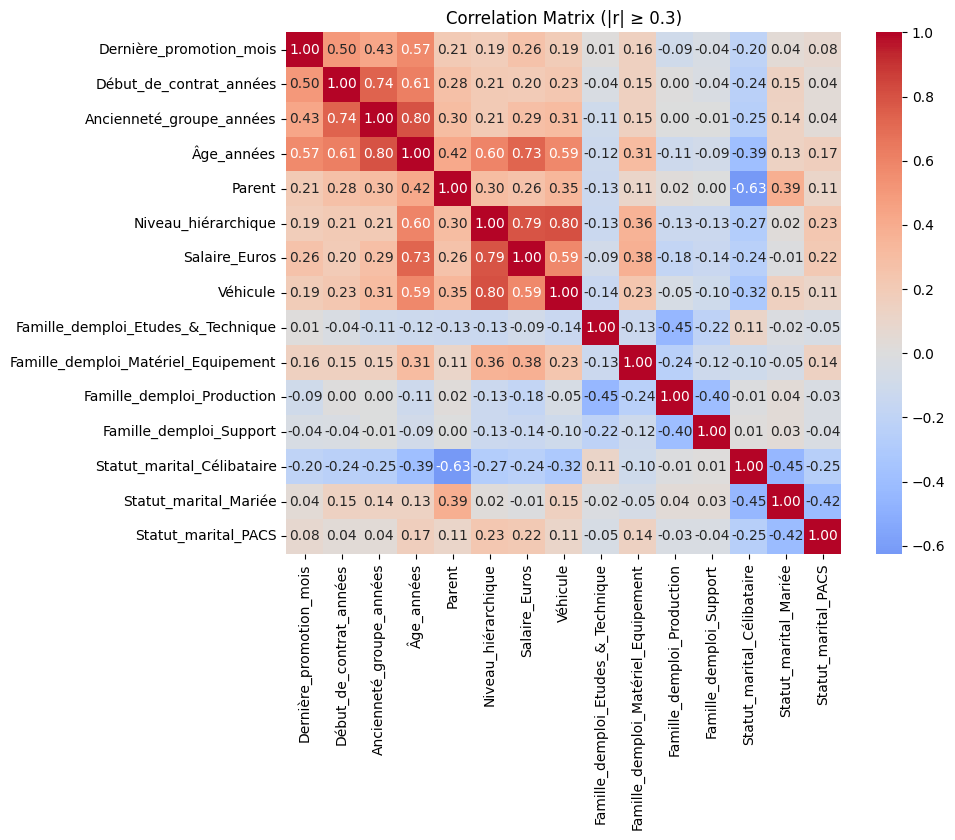

In [13]:
analysis_RH.plot_matrix_correlation(threshold=0.3)

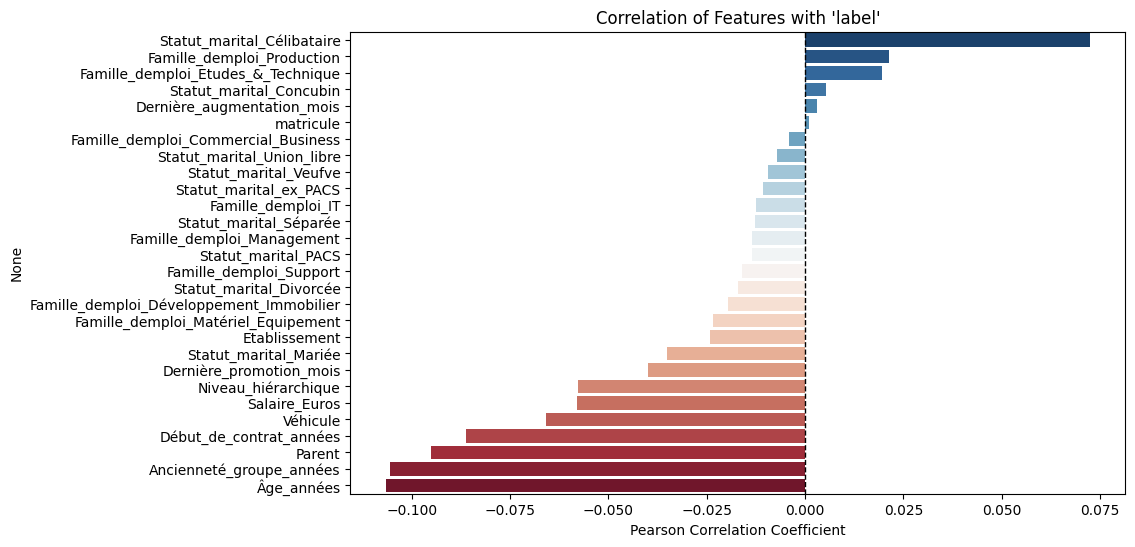

Statut_marital_Célibataire                  0.072513
Famille_demploi_Production                  0.021242
Famille_demploi_Etudes_&_Technique          0.019479
Statut_marital_Concubin                     0.005451
Dernière_augmentation_mois                  0.003011
matricule                                   0.001034
Famille_demploi_Commercial_Business        -0.003957
Statut_marital_Union_libre                 -0.007057
Statut_marital_Veufve                      -0.009308
Statut_marital_ex_PACS                     -0.010682
Famille_demploi_IT                         -0.012404
Statut_marital_Séparée                     -0.012591
Famille_demploi_Management                 -0.013484
Statut_marital_PACS                        -0.013513
Famille_demploi_Support                    -0.016009
Statut_marital_Divorcée                    -0.016953
Famille_demploi_Développement_Immobilier   -0.019704
Famille_demploi_Matériel_Equipement        -0.023319
Etablissement                              -0.

In [14]:
analysis_RH.target_correlation('label')

### Analyse de la corrélation

La matrice de corrélation permet d'identifier des dépendances linéaires simples entre variables numériques ou booléennes encodées.  
Il faut toutefois rester prudent dans l'interprétation :

- une corrélation faible avec la cible ne signifie pas qu'une variable est inutile en apprentissage supervisé ;
- plusieurs variables faiblement corrélées prises ensemble peuvent tout de même apporter de l'information ;
- la corrélation ne renseigne ni sur une relation causale, ni sur des interactions non linéaires.

On utilise donc cette étape comme un outil exploratoire, pas comme un critère suffisant pour exclure une variable.

### Analyse d'un parcours d’un employé ayant démissionné VS employé n'ayant pas démissionné

In [15]:
# Sélection robuste de deux employés pour illustrer un parcours :
# - un employé qui n'a pas démissionné dans les 6 mois suivants
# - un employé qui a démissionné dans les 6 mois suivants
# On essaie de prendre la même famille d'emploi pour rendre la comparaison plus pertinente.

famille_ref = (
    df.groupby("Famille d'emploi")["label"]
      .agg(["sum", "count"])
      .query("sum > 0 and count > 1")
      .index[0]
)

n_demission = (
    df[(df["label"] == 0) & (df["Famille d'emploi"] == famille_ref)]
    .sort_values("matricule")
    .iloc[0]
)
n_dem_matricule = n_demission["matricule"]

demission = (
    df[(df["label"] == 1) & (df["Famille d'emploi"] == famille_ref)]
    .sort_values("matricule")
    .iloc[0]
)
dem_matricule = demission["matricule"]

print(f"Famille d'emploi retenue : {famille_ref}")
print(f"Employé non démissionnaire : {n_dem_matricule}")
print(f"Employé démissionnaire     : {dem_matricule}")

Famille d'emploi retenue : Commercial/Business
Employé non démissionnaire : 1
Employé démissionnaire     : 1


Aller chercher toutes les données de ces deux employés dans le dataframe traité pour reconstituer leur historique à partir de leurs matricules

In [16]:
n_dem_parcours = get_parcours(df, n_dem_matricule)
dem_parcours = get_parcours(df, dem_matricule)

Nombre de lignes pour le matricule 1 : 5
Nombre de lignes pour le matricule 1 : 5


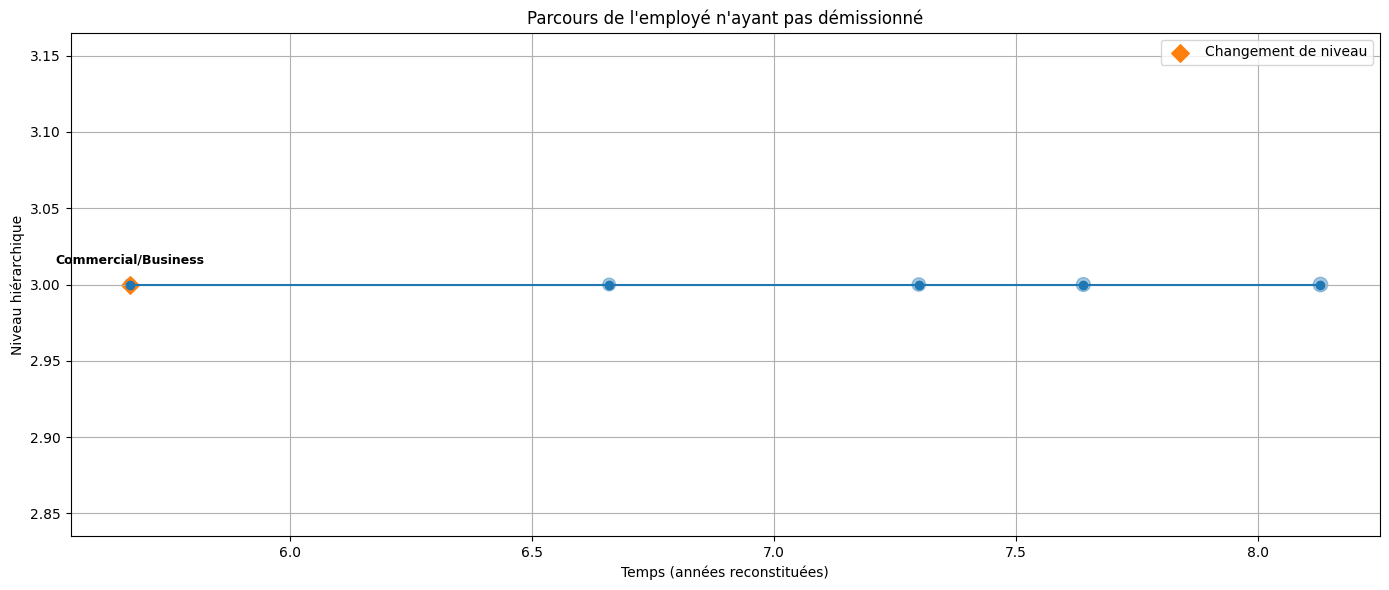

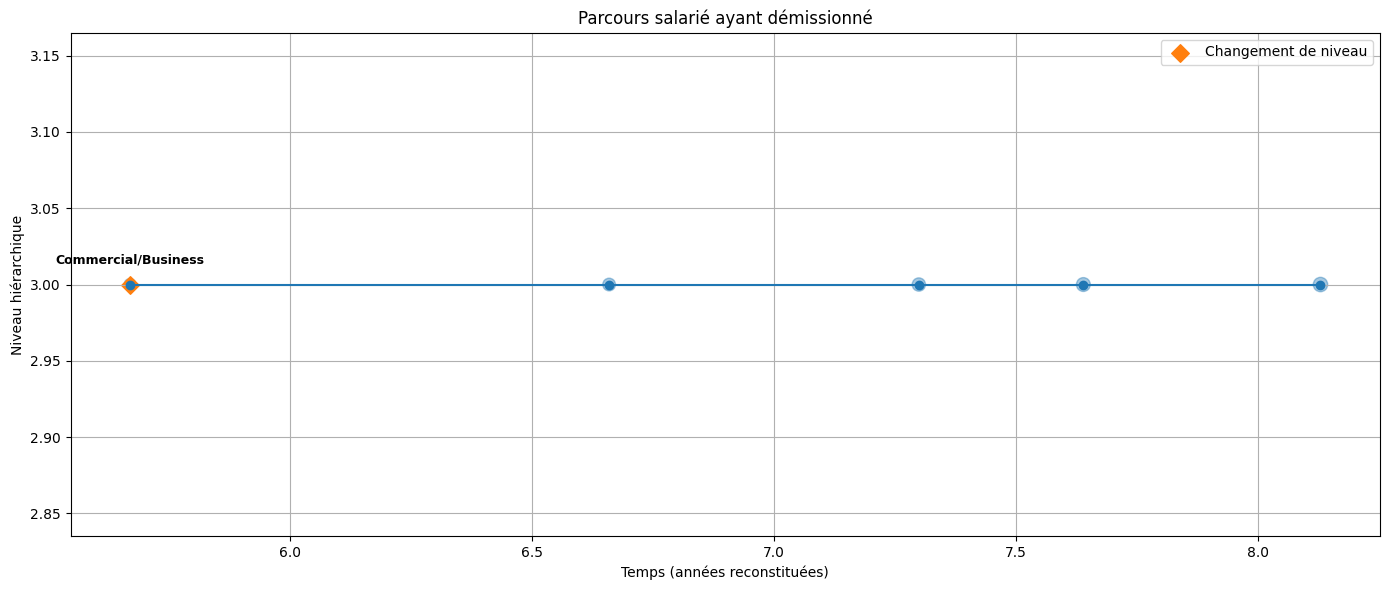

In [17]:
plot_parcours(n_dem_parcours, title="Parcours de l'employé n'ayant pas démissionné")
plot_parcours(dem_parcours, "Parcours salarié ayant démissionné")

### Commentaires sur les deux parcours

L'objectif ici n'est pas d'établir une causalité à partir de deux exemples individuels, mais d'illustrer la nature longitudinale du jeu de données :
un même employé peut apparaître plusieurs fois à des dates différentes.

Cette observation a une conséquence méthodologique importante pour la suite :
si l'on sépare aléatoirement les lignes du jeu de données, un même employé peut se retrouver à la fois dans l'entraînement et dans le test.
Cela créerait une fuite d'information.  
Pour éviter ce problème, la séparation train/test sera faite plus bas par `matricule` et non par ligne.

## 2. Analyse des variables sensibles et biais potentiels

### Identifier les variables pouvant être considérées comme sensibles ou proxies, i.e. des variables qui permettent de deviner ou d’inférer des caractéristiques sensibles (e.g. la variable temps de pause maternité peut potentiellement révéler le sexe). (justifier votre réponse et classification)

Dans le cadre du RGPD et du Code du travail français, certaines variables sont considérées comme sensibles car elles exposent à un risque de discrimination ou d'atteinte à la vie privée.

### Variables directement sensibles

| Variable | Motif |
|---|---|
| `matricule` | Identifiant direct de l'individu |
| `Âge (années)` | Caractéristique protégée (discrimination) |
| `Statut marital` | Donnée relevant de la vie privée |
| `Parent` | Vecteur fréquent de discrimination à l'emploi |
| `Salaire (Euros)` | Donnée confidentielle ; discriminante si croisée |

### Variables à risque indirect (proxys potentiels)

| Variable | Biais potentiel |
|---|---|
| `Famille d'emploi` | Souvent corrélée au genre |
| `Niveau hiérarchique` | Proxy possible du genre ou de l'âge |
| `Ancienneté groupe` | Pénalise les interruptions de carrière (congés parentaux) |
| `Établissement` | Peut refléter une répartition corrélée à l'origine ou au niveau de vie |
| `Véhicule` | Indicateur indirect du niveau de vie |

Conclusion : le matricule doit être exclu de toute analyse : en tant qu'identifiant direct, il ne présente aucune valeur prédictive et expose inutilement à un risque de réidentification.

Pour les variables restantes, on suppose que les données ont préalablement fait l'objet d'un traitement d'anonymisation — perturbation des âges, généralisation des salaires, suppression ou codage des variables les plus exposées. Cette hypothèse permet de manipuler le jeu de données dans son état actuel, sans transformation supplémentaire. Elle n'exonère pas pour autant d'une vigilance sur les variables à risque indirect, dont le potentiel discriminatoire peut persister après anonymisation, notamment par croisement.

## 3. Apprentissage automatique

Entrainement de trois modèles transparents : 
-  1 modèle à base d’arbres (XGBoost)
-  1  modèle  statistique  classique  (LogisticRegression)
-  1 modèle linéaire généralisé (GAM) 


In [18]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve
)

from xgboost import XGBClassifier
from pygam import LogisticGAM, s, f

from data_analysis import print_fairness_table, plot_fairness_attribute

In [ ]:
# =========================
# Split train/test par employé
# =========================

X = processed.drop(["label", "matricule"], axis=1).copy()
y = processed["label"].copy()
groups = processed["matricule"].copy()

gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
train_idx, test_idx = next(gss_outer.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train, groups_test_ids = groups.iloc[train_idx].copy(), groups.iloc[test_idx].copy()

print("Nombre de lignes train :", len(X_train))
print("Nombre de lignes test  :", len(X_test))
print("Nombre de matricules train :", groups_train.nunique())
print("Nombre de matricules test  :", groups_test_ids.nunique())
print("Intersection des matricules train/test :", len(set(groups_train).intersection(set(groups_test_ids))))

def build_gam_terms(X_df):
    terms = None
    for i, col in enumerate(X_df.columns):
        series = X_df[col]
        n_unique = series.nunique(dropna=False)

        is_binary = (
            str(series.dtype) == "bool"
            or set(pd.Series(series).dropna().unique()).issubset({0, 1, False, True})
            or n_unique <= 2
        )

        term = f(i) if is_binary else s(i)
        terms = term if terms is None else terms + term
    return terms

def build_models(X_df, y_train_series):
    pipeline_linear = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    pipeline_xgb = Pipeline([
        ("model", XGBClassifier(
            eval_metric="logloss",
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_train_series == 0).sum() / max((y_train_series == 1).sum(), 1),
            random_state=0
        ))
    ])

    model_gam = LogisticGAM(build_gam_terms(X_df), max_iter=300)

    return {
        "Logistic Regression": pipeline_linear,
        "XGBoost": pipeline_xgb,
        "GAM": model_gam
    }

def fit_model(model_name, model, X_fit, y_fit):
    if model_name == "GAM":
        model.fit(X_fit.to_numpy(), y_fit.to_numpy())
    else:
        model.fit(X_fit, y_fit)
    return model

def predict_scores(model_name, model, X_eval):
    if model_name == "GAM":
        return np.asarray(model.predict_proba(X_eval.to_numpy())).reshape(-1)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_eval)
        return 1 / (1 + np.exp(-scores))
    raise ValueError(f"Le modèle {model_name} ne fournit pas de score exploitable.")

def find_best_threshold(y_true, scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    if len(thresholds) == 0:
        return 0.5

    f1_values = 2 * precisions[:-1] * recalls[:-1] / np.clip(precisions[:-1] + recalls[:-1], 1e-12, None)
    best_idx = int(np.nanargmax(f1_values))
    return float(thresholds[best_idx])

# Sous-split de calibration, toujours par matricule, pour choisir un seuil de décision
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
subtrain_idx, valid_idx = next(gss_inner.split(X_train, y_train, groups=groups_train))

X_subtrain, X_valid = X_train.iloc[subtrain_idx].copy(), X_train.iloc[valid_idx].copy()
y_subtrain, y_valid = y_train.iloc[subtrain_idx].copy(), y_train.iloc[valid_idx].copy()

models = build_models(X_train, y_train)
thresholds = {}

for name, model in models.items():
    fit_model(name, model, X_subtrain, y_subtrain)
    valid_scores = predict_scores(name, model, X_valid)
    thresholds[name] = find_best_threshold(y_valid, valid_scores)

# Réentraînement final sur tout le train
models = build_models(X_train, y_train)
for name, model in models.items():
    fit_model(name, model, X_train, y_train)

print("Seuils de décision retenus :")
for name, thr in thresholds.items():
    print(f"- {name}: {thr:.3f}")

Nombre de lignes train : 19039
Nombre de lignes test  : 4818
Nombre de matricules train : 2140
Nombre de matricules test  : 536
Intersection des matricules train/test : 0
Seuils de décision retenus :
- Logistic Regression: 0.679
- XGBoost: 0.543
- GAM: 0.072


In [20]:
results = {}

for name, model in models.items():
    y_score = predict_scores(name, model, X_test)
    threshold = thresholds.get(name, 0.5)
    y_pred = (y_score >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_test, y_score),
        "roc_auc": roc_auc_score(y_test, y_score),
        "threshold": threshold
    }

    results[name] = {
        "model": model,
        "y_score": pd.Series(y_score, index=X_test.index),
        "y_pred": pd.Series(y_pred, index=X_test.index),
        "metrics": metrics
    }

    print(f"\n===== {name} =====")
    print("Seuil :", round(threshold, 3))
    print("Accuracy :", round(metrics["accuracy"], 4))
    print("Balanced accuracy :", round(metrics["balanced_accuracy"], 4))
    print("Precision :", round(metrics["precision"], 4))
    print("Recall :", round(metrics["recall"], 4))
    print("F1 :", round(metrics["f1"], 4))
    print("PR-AUC :", round(metrics["pr_auc"], 4))
    print("ROC-AUC :", round(metrics["roc_auc"], 4))
    print("Confusion matrix :")
    print(confusion_matrix(y_test, y_pred))
    print("Classification report :")
    print(classification_report(y_test, y_pred, zero_division=0))

results_summary = pd.DataFrame({name: value["metrics"] for name, value in results.items()}).T
results_summary


===== Logistic Regression =====
Seuil : 0.679
Accuracy : 0.8458
Balanced accuracy : 0.6055
Precision : 0.0623
Recall : 0.352
F1 : 0.1059
PR-AUC : 0.0481
ROC-AUC : 0.7155
Confusion matrix :
[[4031  662]
 [  81   44]]
Classification report :
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      4693
           1       0.06      0.35      0.11       125

    accuracy                           0.85      4818
   macro avg       0.52      0.61      0.51      4818
weighted avg       0.96      0.85      0.89      4818


===== XGBoost =====
Seuil : 0.543
Accuracy : 0.8032
Balanced accuracy : 0.6342
Precision : 0.0608
Recall : 0.456
F1 : 0.1073
PR-AUC : 0.0569
ROC-AUC : 0.7045
Confusion matrix :
[[3813  880]
 [  68   57]]
Classification report :
              precision    recall  f1-score   support

           0       0.98      0.81      0.89      4693
           1       0.06      0.46      0.11       125

    accuracy                           

,accuracy,balanced_accuracy,precision,recall,f1,pr_auc,roc_auc,threshold
Logistic Regression,0.845787,0.605469,0.062323,0.352,0.105897,0.048117,0.715527,0.678759
XGBoost,0.803238,0.634243,0.060832,0.456,0.107345,0.056922,0.704532,0.542783
GAM,0.859278,0.604608,0.065934,0.336,0.110236,0.052711,0.712324,0.071765


In [21]:
min_group_size = 50

groupes_test = pd.DataFrame(index=X_test.index)
groupes_test["Tranche_age"] = pd.cut(
    df.loc[X_test.index, "Âge (années)"],
    bins=[0, 30, 40, 50, 65, np.inf],
    labels=["<30", "30-39", "40-49", "50-64", "65+"],
    right=False
)
groupes_test["Parent"] = df.loc[X_test.index, "Parent"].map({0: "Non parent", 1: "Parent"})
groupes_test["Statut_marital"] = df.loc[X_test.index, "Statut marital"]
groupes_test["Famille_emploi"] = df.loc[X_test.index, "Famille d'emploi"]

def compute_group_metrics(y_true, y_pred, group_values, min_size=50):
    temp = pd.DataFrame({
        "y_true": pd.Series(np.asarray(y_true).astype(int), index=group_values.index),
        "y_pred": pd.Series(np.asarray(y_pred).astype(int), index=group_values.index),
        "group": group_values.astype("object")
    }).dropna(subset=["group"])

    rows = []
    for group_name, g in temp.groupby("group"):
        n = len(g)
        if n < min_size:
            continue

        yt = g["y_true"]
        yp = g["y_pred"]

        tp = ((yt == 1) & (yp == 1)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()

        rows.append({
            "group": group_name,
            "n": n,
            "prevalence": yt.mean(),
            "selection_rate": yp.mean(),
            "accuracy": (yt == yp).mean(),
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "tpr": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "precision": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn
        })

    if not rows:
        return pd.DataFrame()

    metrics_df = pd.DataFrame(rows).sort_values("n", ascending=False)

    # Disparate Impact : rapport du taux de sélection de chaque groupe
    # relativement au groupe ayant le taux de sélection maximal.
    max_selection_rate = metrics_df["selection_rate"].max()
    metrics_df["disparate_impact"] = metrics_df["selection_rate"] / max_selection_rate if max_selection_rate > 0 else np.nan

    return metrics_df

all_metrics = []

for model_name, output in results.items():
    y_hat = output["y_pred"]

    for attribute in groupes_test.columns:
        metrics_df = compute_group_metrics(y_test, y_hat, groupes_test[attribute], min_group_size)
        if metrics_df.empty:
            continue

        metrics_df.insert(0, "attribute", attribute)
        metrics_df.insert(0, "model", model_name)
        all_metrics.append(metrics_df)

fairness_by_group = pd.concat(all_metrics, ignore_index=True)
fairness_by_group.head()

,model,attribute,group,n,prevalence,selection_rate,accuracy,fpr,fnr,tpr,precision,tp,tn,fp,fn,disparate_impact
0,Logistic Regression,Tranche_age,40-49,1680,0.019643,0.005357,0.977381,0.004250,0.939394,0.060606,0.222222,2,1640,7,31,0.007250
1,Logistic Regression,Tranche_age,30-39,1458,0.040466,0.113169,0.871056,0.105075,0.694915,0.305085,0.109091,18,1252,147,41,0.153161
2,Logistic Regression,Tranche_age,50-64,806,0.002481,0.000000,0.997519,0.000000,1.000000,0.000000,NaN,0,804,0,2,0.000000
3,Logistic Regression,Tranche_age,<30,720,0.043056,0.738889,0.284722,0.737300,0.225806,0.774194,0.045113,24,181,508,7,1.000000
4,Logistic Regression,Tranche_age,65+,154,0.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,0,154,0,0,0.000000


FPR / FNR / DISPARATE IMPACT — FAMILLE D'EMPLOI
              model               group    n prevalence selection_rate    fpr     fnr
                GAM Commercial/Business  372      1.88%          7.53%  7.40%  85.71%
                GAM  Etudes & Technique  863      3.82%         20.51% 19.28%  48.48%
                GAM                  IT  117      3.42%          0.85%  0.88% 100.00%
                GAM Matériel/Equipement  377      1.59%          1.33%  1.35% 100.00%
                GAM          Production 2155      2.97%         14.94% 14.49%  70.31%
                GAM             Support  888      1.24%         11.71% 11.29%  54.55%
Logistic Regression Commercial/Business  372      1.88%          4.30%  4.11%  85.71%
Logistic Regression  Etudes & Technique  863      3.82%         19.93% 19.04%  57.58%
Logistic Regression                  IT  117      3.42%          0.00%  0.00% 100.00%
Logistic Regression Matériel/Equipement  377      1.59%          0.00%  0.00% 100.00%
Logist

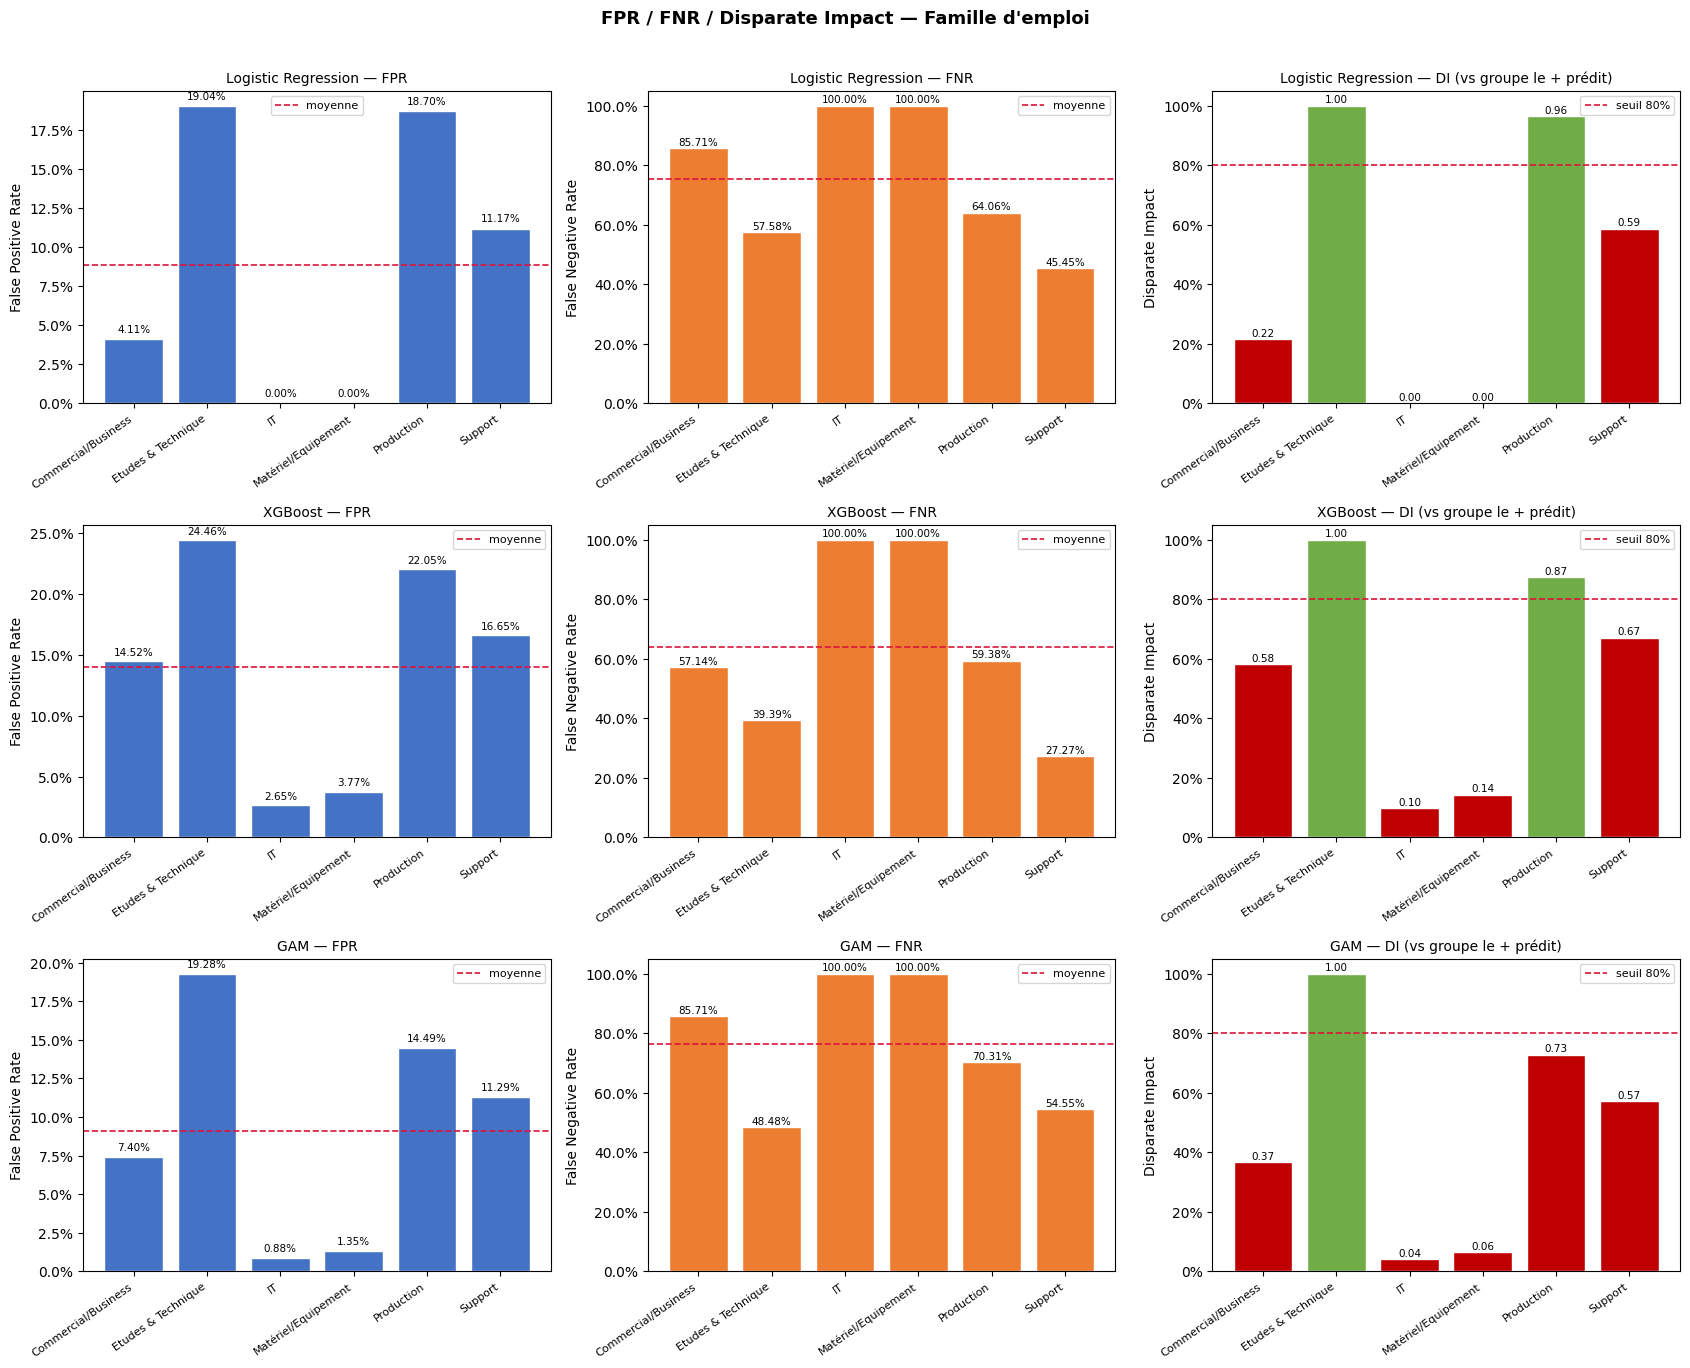

FPR / FNR / DISPARATE IMPACT — STATUT MARITAL
              model       group    n prevalence selection_rate    fpr     fnr
                GAM    Concubin  226      2.65%         13.72% 14.09% 100.00%
                GAM Célibataire 1068      4.03%         43.45% 42.73%  39.53%
                GAM  Divorcé(e)  290      2.41%          1.03%  0.35%  71.43%
                GAM    Marié(e) 2027      1.68%          3.85%  3.66%  85.29%
                GAM        PACS  862      3.36%          5.34%  4.44%  68.97%
                GAM   Séparé(e)   83      2.41%          0.00%  0.00% 100.00%
                GAM Union libre  219      1.83%          6.85%  6.98% 100.00%
Logistic Regression    Concubin  226      2.65%         20.35% 20.00%  66.67%
Logistic Regression Célibataire 1068      4.03%         50.56% 49.85%  32.56%
Logistic Regression  Divorcé(e)  290      2.41%          0.00%  0.00% 100.00%
Logistic Regression    Marié(e) 2027      1.68%          3.31%  2.96%  76.47%
Logistic Regressio

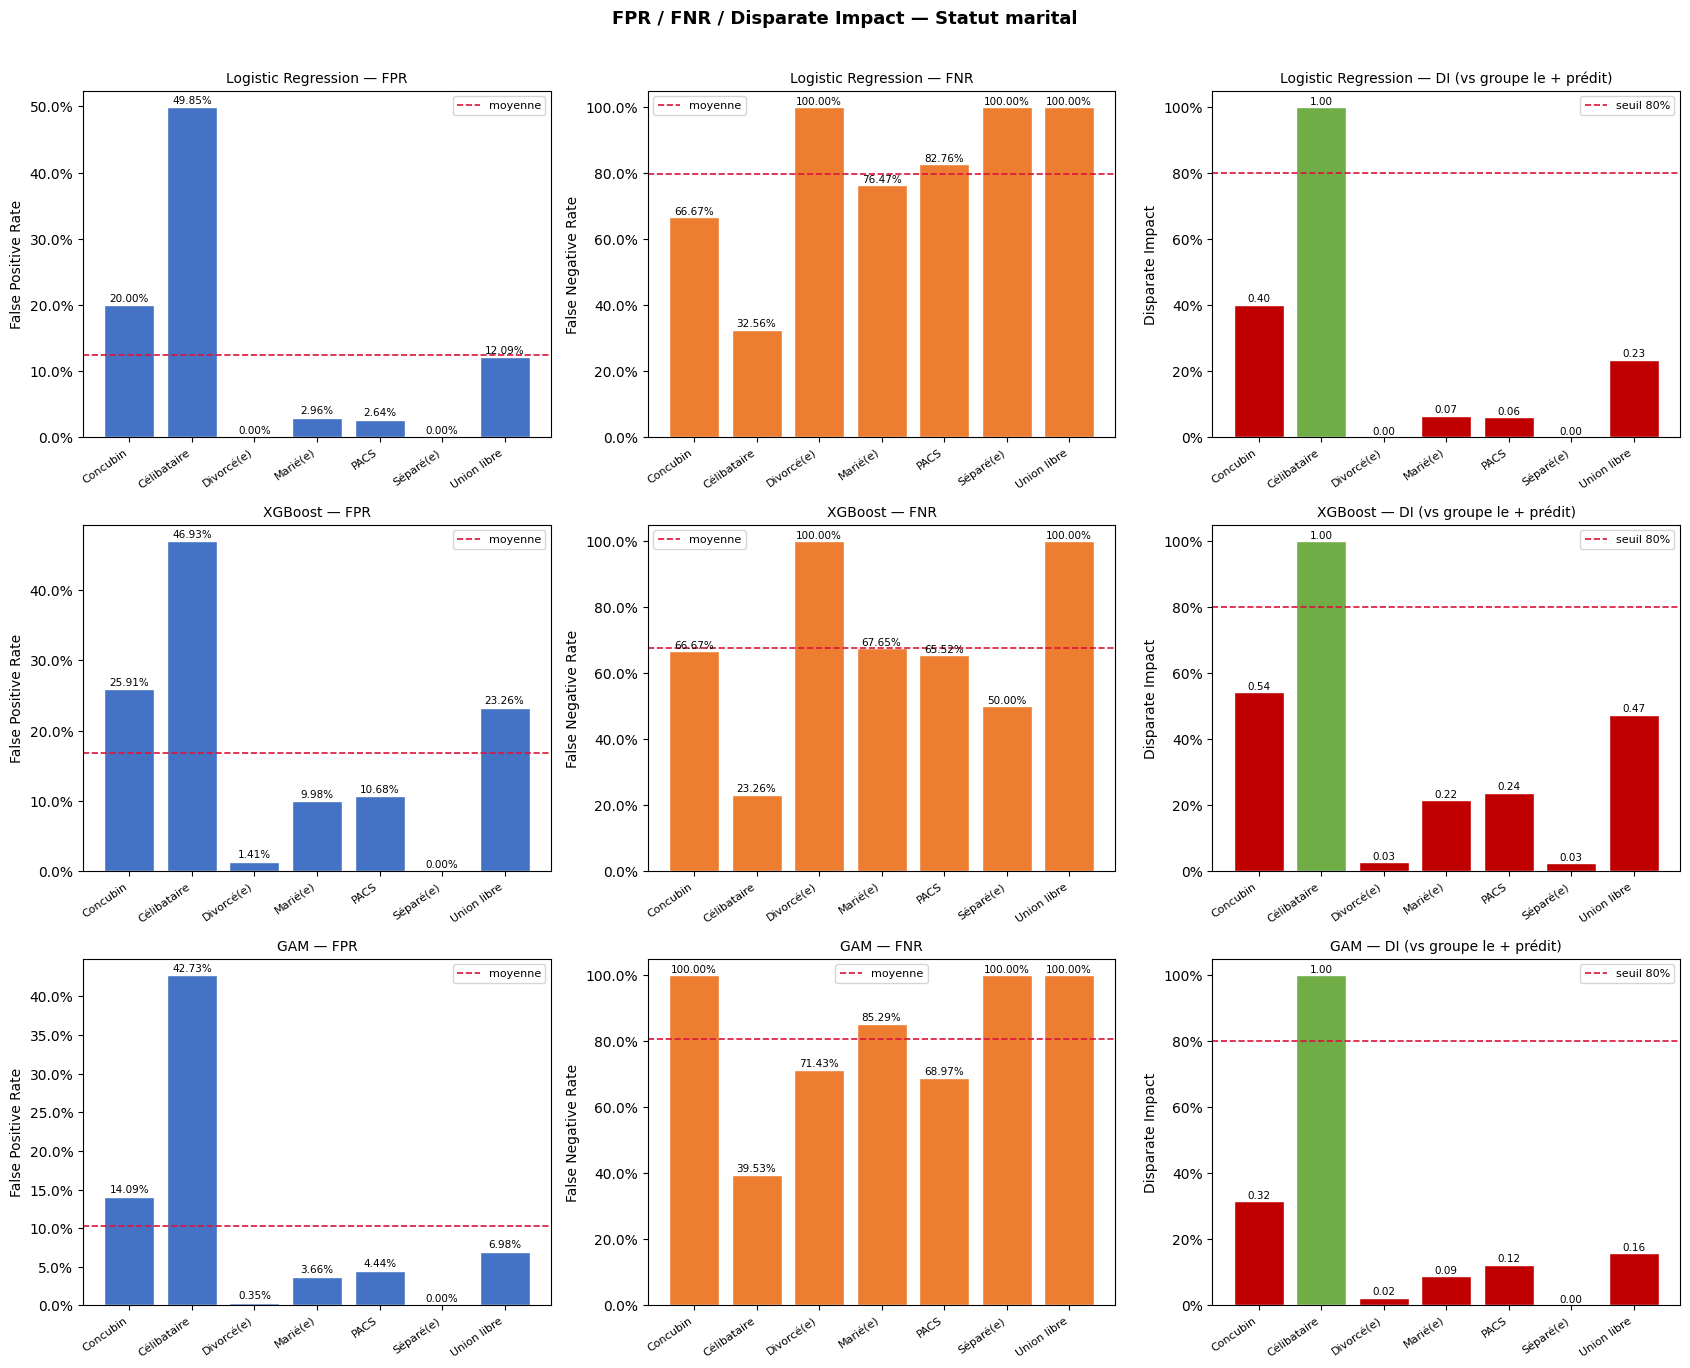

FPR / FNR / DISPARATE IMPACT — TRANCHE D'ÂGE
              model group    n prevalence selection_rate    fpr     fnr
                GAM 30-39 1458      4.05%         19.89% 18.87%  55.93%
                GAM 40-49 1680      1.96%          1.37%  1.40% 100.00%
                GAM 50-64  806      0.25%          0.25%  0.25% 100.00%
                GAM   65+  154      0.00%          0.00%  0.00%       —
                GAM   <30  720      4.31%         44.72% 44.41%  48.39%
Logistic Regression 30-39 1458      4.05%         11.32% 10.51%  69.49%
Logistic Regression 40-49 1680      1.96%          0.54%  0.43%  93.94%
Logistic Regression 50-64  806      0.25%          0.00%  0.00% 100.00%
Logistic Regression   65+  154      0.00%          0.00%  0.00%       —
Logistic Regression   <30  720      4.31%         73.89% 73.73%  22.58%
            XGBoost 30-39 1458      4.05%         32.30% 31.09%  38.98%
            XGBoost 40-49 1680      1.96%          5.06%  5.16% 100.00%
            XGBoost

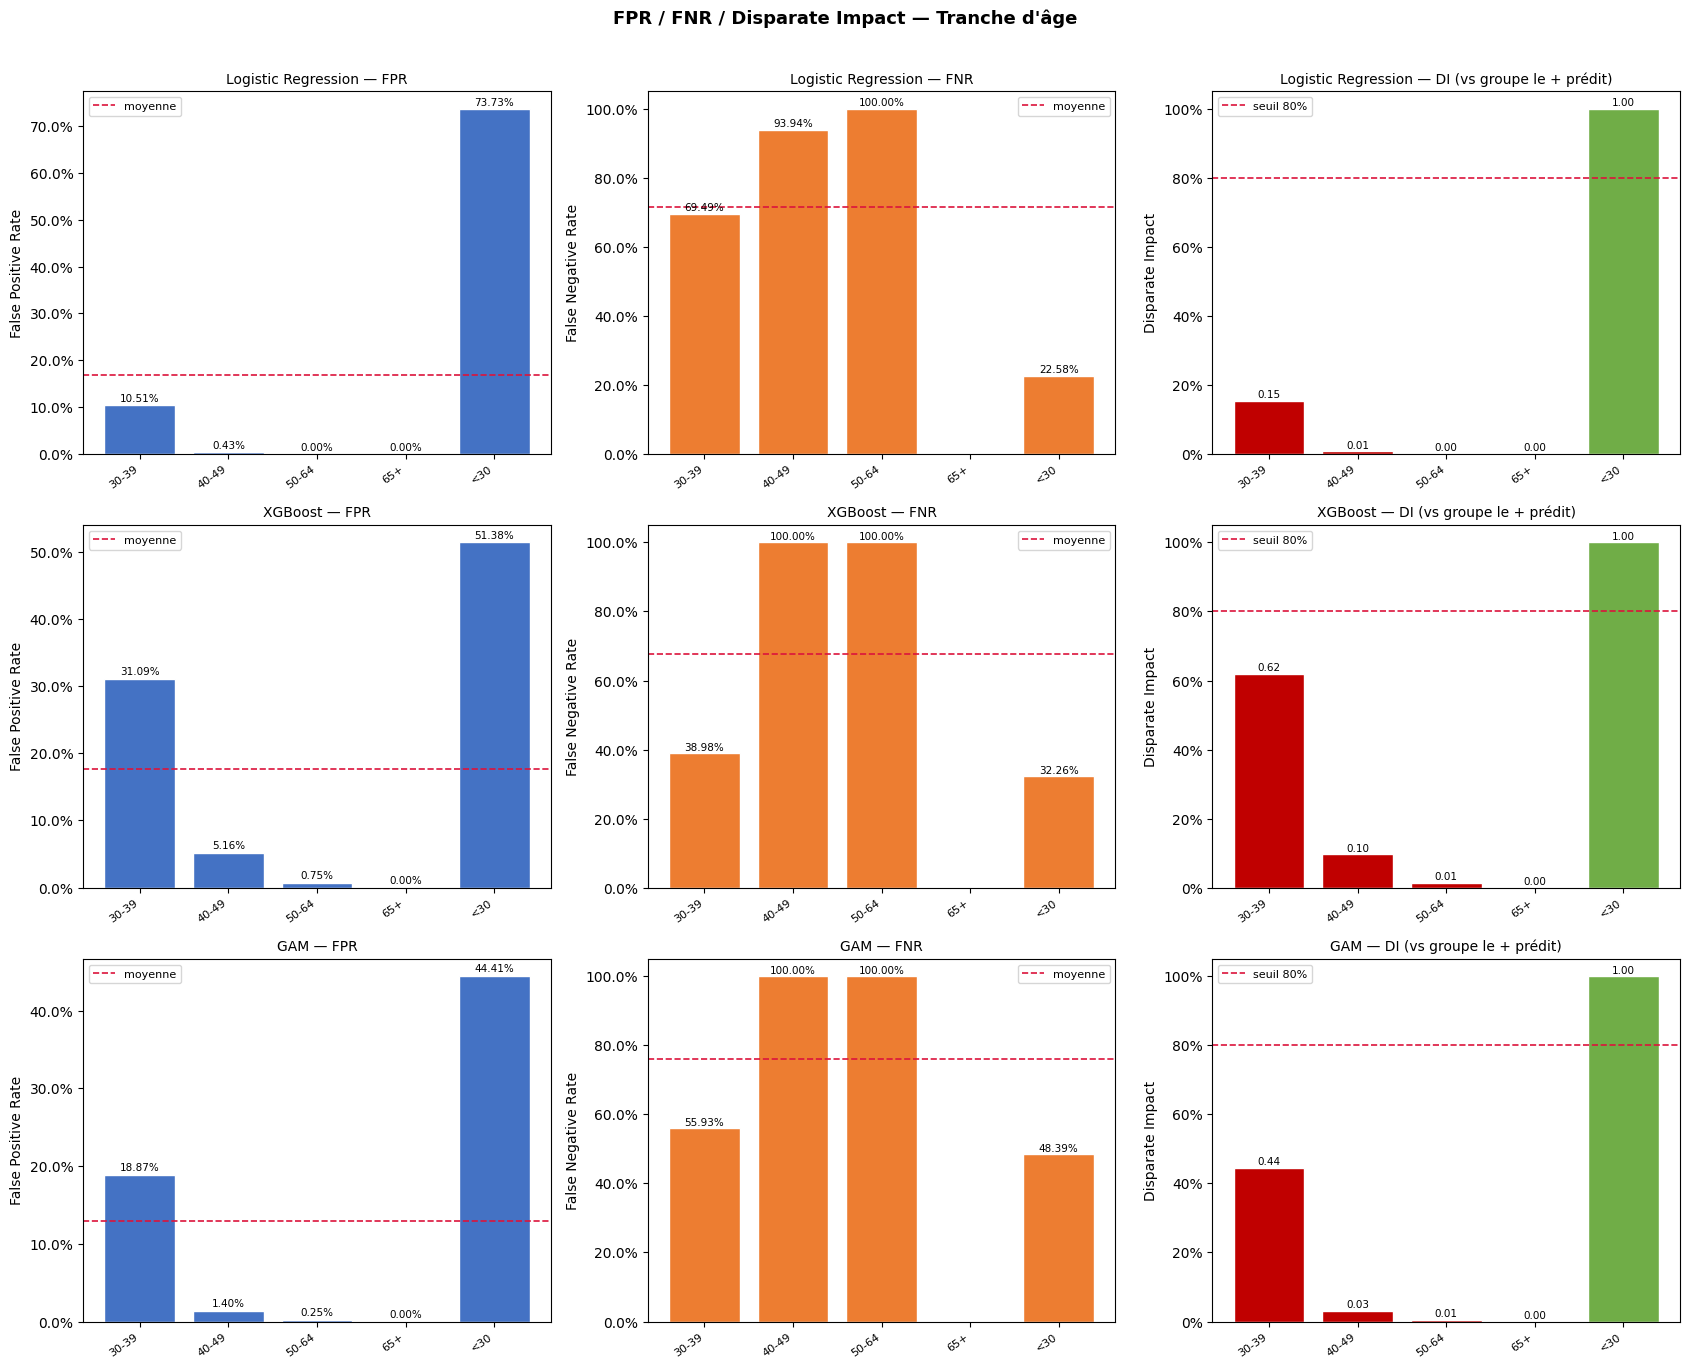

In [22]:
print("=" * 65)
print("FPR / FNR / DISPARATE IMPACT — FAMILLE D'EMPLOI")
print("=" * 65)
print_fairness_table(fairness_by_group, "Famille_emploi")
plot_fairness_attribute(fairness_by_group, "Famille_emploi", "Famille d'emploi")

print("=" * 65)
print("FPR / FNR / DISPARATE IMPACT — STATUT MARITAL")
print("=" * 65)
print_fairness_table(fairness_by_group, "Statut_marital")
plot_fairness_attribute(fairness_by_group, "Statut_marital", "Statut marital")

print("=" * 65)
print("FPR / FNR / DISPARATE IMPACT — TRANCHE D'ÂGE")
print("=" * 65)
print_fairness_table(fairness_by_group, "Tranche_age")
plot_fairness_attribute(fairness_by_group, "Tranche_age", "Tranche d'âge")

### Observe-t-on un trade-off performance / équité ?

L'analyse d'équité doit être interprétée conjointement avec les performances globales.

Un modèle peut sembler « équitable » simplement parce qu'il prédit très peu de cas positifs, ce qui réduit artificiellement certains écarts mais le rend peu utile opérationnellement.
À l'inverse, un modèle plus performant sur la détection des démissions peut produire davantage de faux positifs dans certains sous-groupes.

Il faut donc regarder simultanément :
- les métriques globales adaptées au déséquilibre de classes ;
- les écarts de FPR/FNR entre sous-groupes ;
- le disparate impact ;
- et la composition des variables utilisées, notamment lorsqu'elles sont sensibles ou fortement proxy.

### Explication post-hoc

In [23]:
# Préparation des données pour SHAP
# - Régression logistique : on explique le modèle après standardisation
# - XGBoost : on peut travailler directement dans l'espace des variables d'entrée
# - GAM : explication plus coûteuse, on limite la taille d'échantillon

X_train_fixed = X_train.copy()
X_test_fixed = X_test.copy()

for col in X_train_fixed.select_dtypes(include=["bool"]).columns:
    X_train_fixed[col] = X_train_fixed[col].astype(int)
    X_test_fixed[col] = X_test_fixed[col].astype(int)

X_train_linear = pd.DataFrame(
    models["Logistic Regression"].named_steps["scaler"].transform(X_train_fixed),
    columns=X_train_fixed.columns,
    index=X_train_fixed.index
)
X_test_linear = pd.DataFrame(
    models["Logistic Regression"].named_steps["scaler"].transform(X_test_fixed),
    columns=X_test_fixed.columns,
    index=X_test_fixed.index
)

In [24]:
import shap

# Régression logistique
explainer_linear = shap.Explainer(models["Logistic Regression"].named_steps["model"], X_train_linear)
shap_values_linear = explainer_linear(X_test_linear)

# XGBoost
explainer_xgb = shap.Explainer(models["XGBoost"].named_steps["model"], X_train_fixed)
shap_values_xgb = explainer_xgb(X_test_fixed)

# GAM
N = min(200, len(X_test_fixed))
background = shap.sample(X_train_fixed, min(100, len(X_train_fixed)), random_state=0)

explainer_gam = shap.Explainer(
    lambda X: models["GAM"].predict_proba(pd.DataFrame(X, columns=X_train_fixed.columns).to_numpy()),
    background
)
shap_values_gam = explainer_gam(X_test_fixed.iloc[:N])

PermutationExplainer explainer: 201it [00:59,  3.14it/s]                         


C:\Users\maloc\AppData\Local\Temp\ipykernel_27584\3340625843.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_linear, X_test_fixed, feature_names=X_test_fixed.columns, title="Logistic Regression")


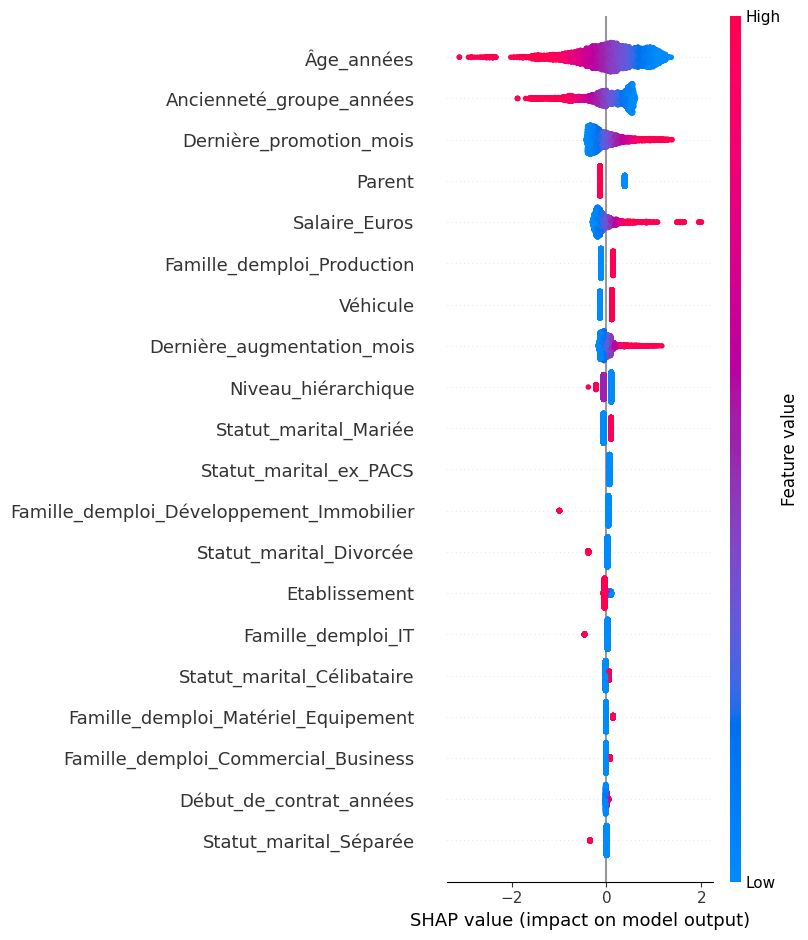

C:\Users\maloc\AppData\Local\Temp\ipykernel_27584\3340625843.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_xgb, X_test_fixed, feature_names=X_test_fixed.columns, title="XGBoost")


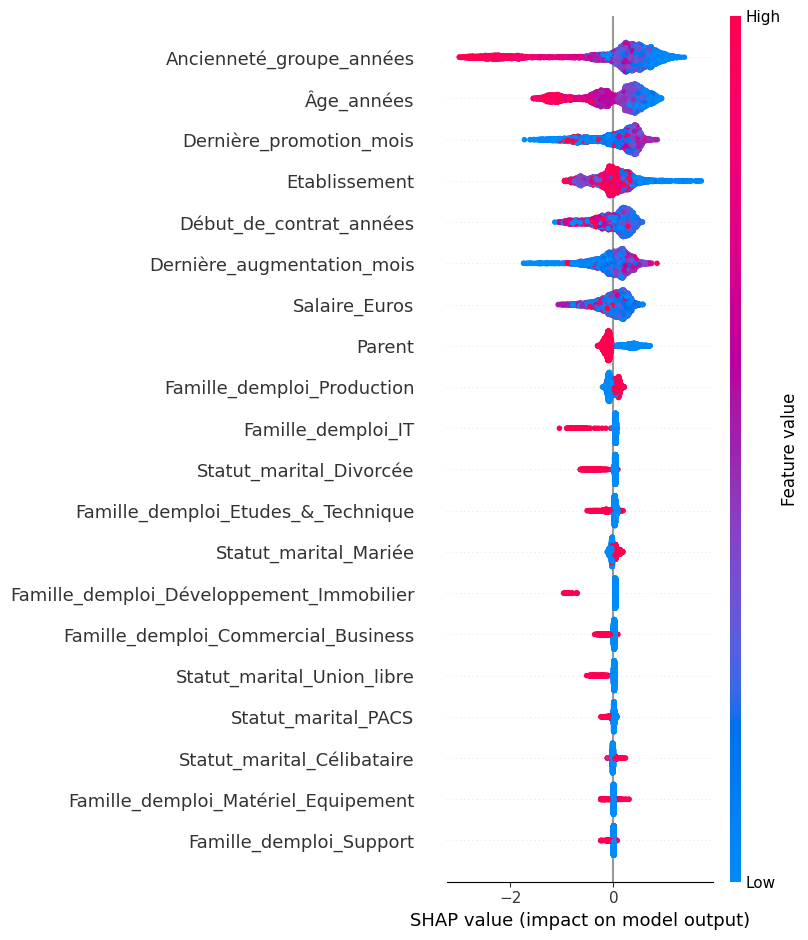

C:\Users\maloc\AppData\Local\Temp\ipykernel_27584\3340625843.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_gam, X_test_fixed[:N], feature_names=X_test_fixed.columns, title="GAM")


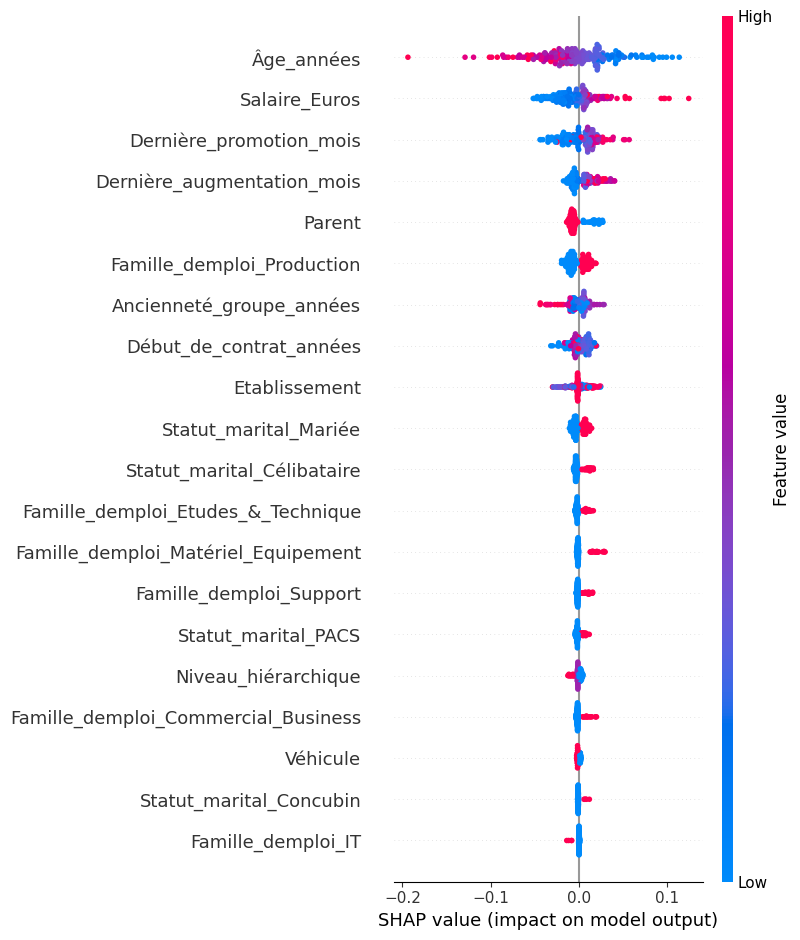

In [25]:
shap.summary_plot(shap_values_linear, X_test_fixed, feature_names=X_test_fixed.columns, title="Logistic Regression")
shap.summary_plot(shap_values_xgb, X_test_fixed, feature_names=X_test_fixed.columns, title="XGBoost")
shap.summary_plot(shap_values_gam, X_test_fixed[:N], feature_names=X_test_fixed.columns, title="GAM")

### Commentaire

Les explications SHAP restent des explications post-hoc : elles décrivent comment le modèle utilise les variables, pas une relation causale réelle dans l'organisation.

La réduction de variables ci-dessous est donc interprétée comme une simplification du modèle :
- pour améliorer la lisibilité ;
- pour tester la robustesse des performances ;
- et pour vérifier si une partie de l'information prédictive provient d'un petit noyau de variables.

Cette étape ne garantit ni l'absence de biais, ni l'absence de proxies sensibles.

In [ ]:
importance = pd.Series(
    np.abs(shap_values_xgb.values).mean(axis=0),
    index=X_test_fixed.columns
).sort_values(ascending=False)

n_keep = max(1, int(np.ceil(0.30 * len(importance))))
selected_columns = importance.head(n_keep).index.tolist()
drop_columns = [col for col in X_test_fixed.columns if col not in selected_columns]

print(f"Nombre de variables conservées : {len(selected_columns)} / {len(importance)}")
print("Variables conservées :")
for col in selected_columns:
    print(f"- {col}: importance moyenne absolue = {importance[col]:.4f}")

Nombre de variables conservées : 9 / 27
Variables conservées :
- Ancienneté_groupe_années: importance moyenne absolue = 0.6767
- Âge_années: importance moyenne absolue = 0.4811
- Dernière_promotion_mois: importance moyenne absolue = 0.3810
- Etablissement: importance moyenne absolue = 0.2723
- Début_de_contrat_années: importance moyenne absolue = 0.2687
- Dernière_augmentation_mois: importance moyenne absolue = 0.2386
- Salaire_Euros: importance moyenne absolue = 0.2068
- Parent: importance moyenne absolue = 0.1811
- Famille_demploi_Production: importance moyenne absolue = 0.0773


## Réentrainement avec un jeu de données réduit.

In [ ]:
X_reduced = processed.drop(["label", "matricule"] + drop_columns, axis=1).copy()
y_reduced = processed["label"].copy()

X_train_red, X_test_red = X_reduced.iloc[train_idx].copy(), X_reduced.iloc[test_idx].copy()
y_train_red, y_test_red = y_reduced.iloc[train_idx].copy(), y_reduced.iloc[test_idx].copy()
groups_train_red = groups.iloc[train_idx].copy()

gss_inner_red = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
subtrain_idx_red, valid_idx_red = next(gss_inner_red.split(X_train_red, y_train_red, groups=groups_train_red))

X_subtrain_red, X_valid_red = X_train_red.iloc[subtrain_idx_red].copy(), X_train_red.iloc[valid_idx_red].copy()
y_subtrain_red, y_valid_red = y_train_red.iloc[subtrain_idx_red].copy(), y_train_red.iloc[valid_idx_red].copy()

models_red = build_models(X_train_red, y_train_red)
thresholds_red = {}

for name, model in models_red.items():
    fit_model(name, model, X_subtrain_red, y_subtrain_red)
    valid_scores_red = predict_scores(name, model, X_valid_red)
    thresholds_red[name] = find_best_threshold(y_valid_red, valid_scores_red)

models_red = build_models(X_train_red, y_train_red)
for name, model in models_red.items():
    fit_model(name, model, X_train_red, y_train_red)

results_red = {}

for name, model in models_red.items():
    y_score_red = predict_scores(name, model, X_test_red)
    threshold_red = thresholds_red.get(name, 0.5)
    y_pred_red = (y_score_red >= threshold_red).astype(int)

    metrics_red = {
        "accuracy": accuracy_score(y_test_red, y_pred_red),
        "balanced_accuracy": balanced_accuracy_score(y_test_red, y_pred_red),
        "precision": precision_score(y_test_red, y_pred_red, zero_division=0),
        "recall": recall_score(y_test_red, y_pred_red, zero_division=0),
        "f1": f1_score(y_test_red, y_pred_red, zero_division=0),
        "pr_auc": average_precision_score(y_test_red, y_score_red),
        "roc_auc": roc_auc_score(y_test_red, y_score_red),
        "threshold": threshold_red
    }

    results_red[name] = metrics_red

    print(f"\n===== {name} (jeu réduit) =====")
    print("Seuil :", round(threshold_red, 3))
    print("Accuracy :", round(metrics_red["accuracy"], 4))
    print("Balanced accuracy :", round(metrics_red["balanced_accuracy"], 4))
    print("Precision :", round(metrics_red["precision"], 4))
    print("Recall :", round(metrics_red["recall"], 4))
    print("F1 :", round(metrics_red["f1"], 4))
    print("PR-AUC :", round(metrics_red["pr_auc"], 4))
    print("ROC-AUC :", round(metrics_red["roc_auc"], 4))
    print("Confusion matrix :")
    print(confusion_matrix(y_test_red, y_pred_red))
    print("Classification report :")
    print(classification_report(y_test_red, y_pred_red, zero_division=0))

results_red_summary = pd.DataFrame(results_red).T
comparison = (
    results_summary.add_suffix("_full")
    .join(results_red_summary.add_suffix("_reduced"), how="outer")
)
comparison


===== Logistic Regression (jeu réduit) =====
Seuil : 0.698
Accuracy : 0.8705
Balanced accuracy : 0.5753
Precision : 0.0584
Recall : 0.264
F1 : 0.0957
PR-AUC : 0.0495
ROC-AUC : 0.7253
Confusion matrix :
[[4161  532]
 [  92   33]]
Classification report :
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      4693
           1       0.06      0.26      0.10       125

    accuracy                           0.87      4818
   macro avg       0.52      0.58      0.51      4818
weighted avg       0.95      0.87      0.91      4818


===== XGBoost (jeu réduit) =====
Seuil : 0.657
Accuracy : 0.8856
Balanced accuracy : 0.5909
Precision : 0.0706
Recall : 0.28
F1 : 0.1127
PR-AUC : 0.0603
ROC-AUC : 0.7185
Confusion matrix :
[[4232  461]
 [  90   35]]
Classification report :
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      4693
           1       0.07      0.28      0.11       125

    accuracy  

,accuracy_full,balanced_accuracy_full,precision_full,recall_full,f1_full,pr_auc_full,roc_auc_full,threshold_full,accuracy_reduced,balanced_accuracy_reduced,precision_reduced,recall_reduced,f1_reduced,pr_auc_reduced,roc_auc_reduced,threshold_reduced
GAM,0.859278,0.604608,0.065934,0.336,0.110236,0.052711,0.712324,0.071765,0.851598,0.616240,0.067449,0.368,0.114002,0.054079,0.719659,0.067858
Logistic Regression,0.845787,0.605469,0.062323,0.352,0.105897,0.048117,0.715527,0.678759,0.870486,0.575320,0.058407,0.264,0.095652,0.049532,0.725348,0.697546
XGBoost,0.803238,0.634243,0.060832,0.456,0.107345,0.056922,0.704532,0.542783,0.885637,0.590884,0.070565,0.280,0.112721,0.060279,0.718507,0.657210


On compare ici les modèles réentraînés sur le jeu de données réduit avec les modèles entraînés sur l'ensemble initial de variables.

L'objectif n'est pas seulement de maximiser une métrique globale, mais aussi d'évaluer :
- la perte éventuelle de performance ;
- la stabilité des résultats ;
- et l'impact d'une simplification du modèle sur l'interprétabilité et l'équité.

### Discussion finale

Du point de vue de la responsabilité de l'entreprise, un modèle de prédiction de démission ne doit jamais être utilisé comme outil de décision automatique isolé.
Il doit au mieux servir d'outil d'aide à la décision, avec supervision humaine, traçabilité, documentation des variables utilisées et audit régulier.

Le principal risque est la discrimination indirecte :
même si certaines variables sensibles sont retirées, des proxies peuvent permettre de reconstituer partiellement des caractéristiques protégées
(ex. situation familiale, interruptions de carrière, structure de rémunération, trajectoires d'emploi, établissement).

Enfin, les méthodes d'explicabilité ont des limites importantes :
- elles expliquent le comportement du modèle, pas la réalité sociale ;
- elles peuvent être instables selon l'échantillon et le modèle ;
- elles ne suffisent pas à démontrer qu'un modèle est juste, non biaisé ou juridiquement acceptable.

En pratique, la qualité d'un tel système dépend autant du protocole d'évaluation, de la gouvernance des données et du cadre d'usage que de l'algorithme lui-même.